### Simple Linear Regression

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm

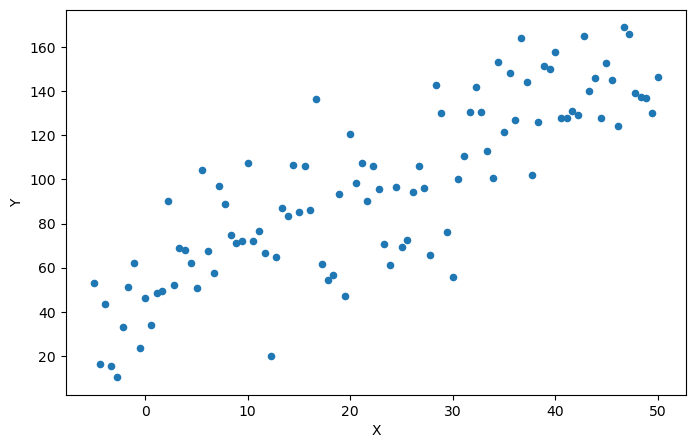

In [24]:
# Generate the data
x = np.linspace(-5, 50, 100)
y = 50 + 2 * x + np.random.normal(0, 20, size=len(x))
data = pd.DataFrame({'X': x, 'Y': y})

data.plot.scatter(x='X', y='Y', figsize=(8,5))
plt.show()

Consider a simple linear model with a single independent variable:

$$y = \beta_0 + \beta_1 X_1 + \epsilon$$

$\epsilon$ is the error term, accounts for deviation from the linear model

By minimizing the residual sum of squares we obtain

$$\hat{\beta} = (X^T X)^{-1} (X^T y)$$

we can quickly derive the vector $\hat{\beta}$ by inverting the matrix $X^T X$

In [25]:
X = sm.add_constant(data.X)
beta = np.linalg.inv(X.T @ X) @ (X.T @ y)
beta

array([49.1851431 ,  2.07660399])

In [26]:
X = sm.add_constant(data.X)
model = sm.OLS(data.Y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.705
Model:                            OLS   Adj. R-squared:                  0.702
Method:                 Least Squares   F-statistic:                     234.7
Date:                Mon, 15 Jun 2026   Prob (F-statistic):           9.27e-28
Time:                        18:10:48   Log-Likelihood:                -448.78
No. Observations:                 100   AIC:                             901.6
Df Residuals:                      98   BIC:                             906.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         49.1851      3.745     13.133      0.0

Note that t-statistics for both parameters are > 10 and the associated p-values are very low, this tells us that both parameters are statistically significant

#### Analysis of Residuals

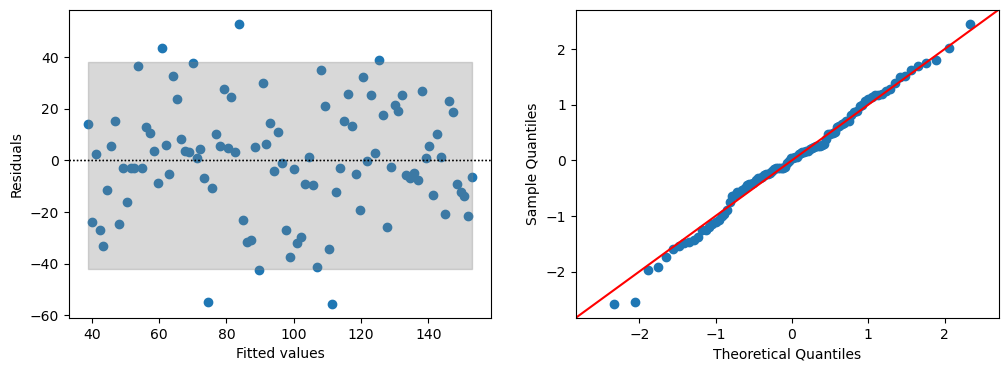

In [27]:
intercept = model.params['const']
slope = model.params['X']
residuals = model.resid.to_numpy()
y_hat = intercept + x * slope

residuals_ci = np.quantile(residuals, [0.025, 0.975])

fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].scatter(y_hat, residuals)
ax[0].axhline(0, lw=1, ls=':', color='black')
ax[0].fill_between(y_hat, residuals_ci[0], residuals_ci[1], alpha=0.3, color='grey')
ax[0].axhline(0, lw=1, ls=':', color='black')
ax[0].set_xlabel('Fitted values')
ax[0].set_ylabel('Residuals')

sm.qqplot(residuals, ax=ax[1], fit=True, line='45')

plt.show()

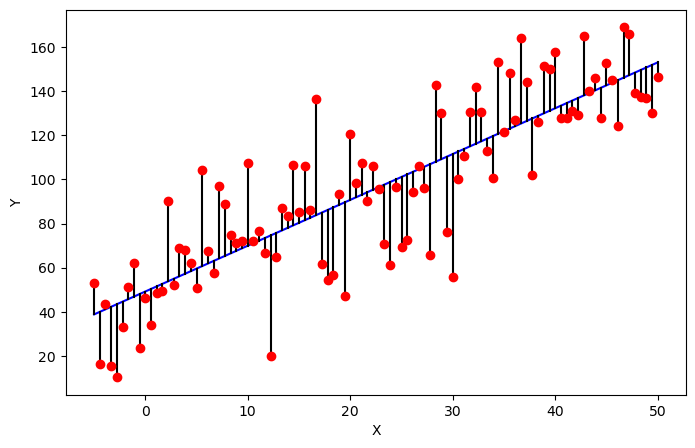

In [29]:
fig, ax = plt.subplots(1, 1, figsize=(8,5))
ax.plot(data.X, y_hat, color='blue')
for i in range(len(data.X)):
    ax.plot((data.X[i], data.X[i]), (y_hat[i], data.Y[i]), 'k-')

ax.scatter(data.X, data.Y, color='red', zorder=4)
ax.set_xlabel('X')
ax.set_ylabel('Y')
plt.show()

### Multiple Linear Regression

Consider now two independent variables, the model simply changes as follows:

$$y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \epsilon$$

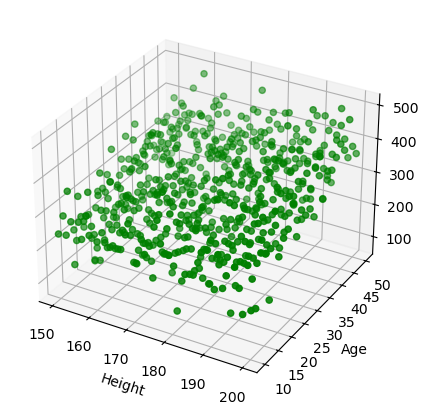

In [30]:
# Generate data
size = 25
X_1, X_2 = np.meshgrid(np.linspace(150, 200, size), np.linspace(10, 50, size), indexing='ij')
data = pd.DataFrame({'Height': X_1.ravel(), 'Age': X_2.ravel()})
data['Y'] = 50 + data.Height + 3 * data.Age + np.random.normal(0, 50, size=size**2)

fig = plt.figure(figsize=(5, 8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(data["Height"], data["Age"], data["Y"], c='g')
ax.set_xlabel("Height")
ax.set_ylabel("Age")
ax.set_zlabel("Y")
plt.show()

In [31]:
# Using the inverse of X.T X
X = data[['Height', 'Age']]
X = sm.add_constant(X)
y = data.Y.to_numpy()
beta = np.linalg.inv(X.T @ X) @ (X.T @ y)
beta

array([37.37714332,  1.00999878,  3.27768186])

In [32]:
X = data[['Height', 'Age']]
X = sm.add_constant(X)


model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.421
Model:                            OLS   Adj. R-squared:                  0.419
Method:                 Least Squares   F-statistic:                     226.1
Date:                Mon, 15 Jun 2026   Prob (F-statistic):           1.56e-74
Time:                        18:11:09   Log-Likelihood:                -3325.6
No. Observations:                 625   AIC:                             6657.
Df Residuals:                     622   BIC:                             6671.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         37.3771     23.731      1.575      0.1

The upper right part of the panel displays the goodness-of-fit measures longside the F-test, which rejects the hypothesis that all coefficients are zero and irrelevant

Similarly, the t-statistics indicate that intercept and both slope coefficients are, unsurprisingly, highly significant

The bottom part of the summary contains the residual diagnostics. The left panel displays skew and kurtosis, which are used to test the normality hypothesis. Both the Omnibus and the Jarque–Bera tests fail to reject the null hypothesis that the residuals are normally distributed. The Durbin–Watson statistic tests for serial correlation in the residuals and has a value near 2, which, given two parameters and 625 observations, fails to reject the
hypothesis of no serial correlation, as outlined in the previous section on this topic.

Lastly, the condition number provides evidence about multicollinearity: it is the ratio of the square roots of the largest and the smallest eigenvalue of the design matrix that contains the input data.

#### Analysis of Residuals

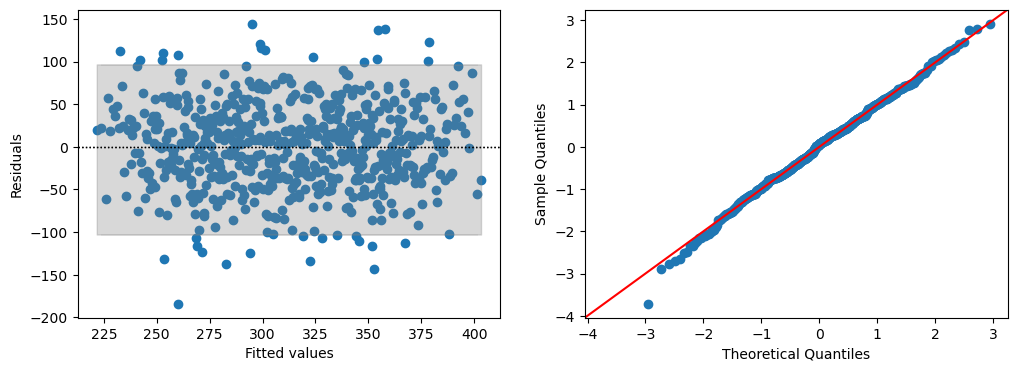

In [33]:
intercept = model.params['const']
residuals = model.resid.to_numpy()
residuals_ci = np.quantile(residuals, [0.025, 0.975])
y_hat = model.predict(X)

fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].scatter(y_hat, residuals)
ax[0].axhline(0, lw=1, ls=':', color='black')
ax[0].fill_between(y_hat, residuals_ci[0], residuals_ci[1], alpha=0.3, color='grey')
ax[0].axhline(0, lw=1, ls=':', color='black')
ax[0].set_xlabel('Fitted values')
ax[0].set_ylabel('Residuals')

sm.qqplot(residuals, ax=ax[1], fit=True, line='45')

plt.show()

#### SGD Training

Note that Gradient Descent is sensitive to feature scaling so we need to scale them

In [34]:
import sklearn as sk

X = data[['Height', 'Age']]
X = sm.add_constant(X)

scaler = sk.preprocessing.StandardScaler()
X_ = scaler.fit_transform(X)

In [38]:
sgd = sk.linear_model.SGDRegressor(
    loss='squared_error', 
    fit_intercept=True, 
    shuffle=True, 
    random_state=42,
    learning_rate='invscaling', 
    eta0=0.01, 
    power_t=0.25)

sgd.fit(X_, y)

coeffs = (sgd.coef_ * scaler.scale_) + scaler.mean_
pd.Series(coeffs, index=X.columns)


const       1.000000
Height    400.779273
Age       500.678593
dtype: float64

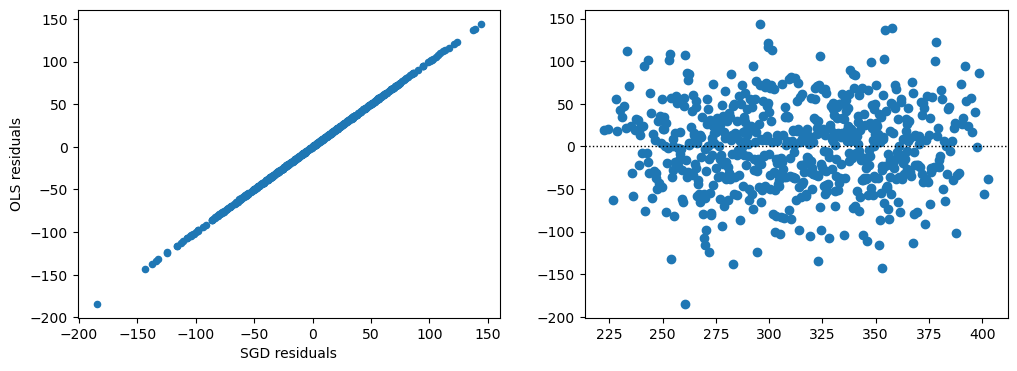

In [42]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))

resids = pd.DataFrame({'SGD residuals': y - sgd.predict(X_),
                       'OLS residuals': y - model.predict(sm.add_constant(X))})
resids.pow(2).sum().div(len(y)).pow(.5)
resids.plot.scatter(x='SGD residuals', y='OLS residuals', ax=ax[0])

ax[1].scatter(sgd.predict(X_), resids['SGD residuals'])
ax[1].axhline(0, lw=1, ls=':', color='black')
plt.show()